# Week 10 — Home exercise 3: What makes a country emit

**Solution proposal.**

The table from the last three weeks, modeled - and a transformation that more than doubles what the
model explains.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col

plt.style.use("ggplot")

co2 = pd.read_csv("../data/co2_emissions.csv")
info = pd.read_csv("../data/country_info.csv")

info = info.rename(columns={"incomeLevel": "income_level"})

panel = co2.merge(
    info[["code", "region", "income_level"]],
    on="code",
    how="left",
    validate="many_to_one",
)

panel = panel[panel["region"] != "Aggregates"]
panel = panel.dropna(subset=["co2_total"])
panel["co2_pc"] = panel["co2_total"] * 1_000_000 / panel["population"]

print(panel.shape, "|", panel["code"].nunique(), "countries")

(4872, 14) | 203 countries


## Why 2021 and not 2023

The exercise said to check rather than take my word for it, so:

In [2]:
needed = ["co2_pc", "gdp_pc", "urban", "electricity", "renew_energy"]

for year in [2019, 2020, 2021, 2022, 2023]:
    rows = panel[panel["year"] == year]
    print(year, "->", len(rows.dropna(subset=needed)), "complete rows of", len(rows))

2019 -> 197 complete rows of 203
2020 -> 197 complete rows of 203
2021 -> 196 complete rows of 203
2022 -> 64 complete rows of 203
2023 -> 0 complete rows of 203


**Zero complete rows in 2023.** `renew_energy` simply stops after 2021 - the World Bank has not
published it for the last two years of the file, and neither has it published `nat_resources`.

This is worth pausing on, because it is not a data-cleaning inconvenience. The most recent year is the
one everybody wants, and the variables you want to explain it with are the ones most likely to be
missing from it. **Recency and completeness pull against each other**, and choosing between them is a
modeling decision you make in the open, not a `dropna` you run quietly.

## 1. The 2021 cross-section

In [3]:
year_2021 = panel[panel["year"] == 2021]
countries = year_2021.dropna(subset=needed)
countries = countries[countries["co2_pc"] > 0]

print("countries in 2021:      ", len(year_2021))
print("with all five variables:", len(countries))
print("lost:                   ", len(year_2021) - len(countries))

countries in 2021:       203
with all five variables: 194
lost:                    9


194 of 203. Nine countries dropped, and it is worth knowing they are gone rather than assuming the
sample is the world.

## 2. The obvious model, and what is wrong with it

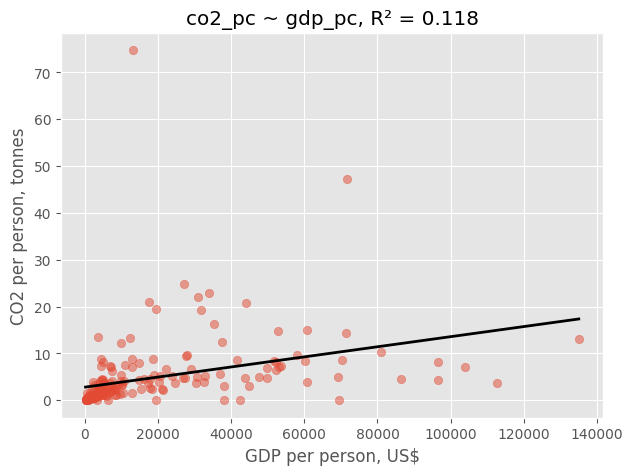

In [4]:
levels = smf.ols("co2_pc ~ gdp_pc", data=countries).fit()

grid = pd.DataFrame({
    "gdp_pc": np.linspace(countries["gdp_pc"].min(), countries["gdp_pc"].max(), 100)
})

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(countries["gdp_pc"], countries["co2_pc"], alpha=0.5)
ax.plot(grid["gdp_pc"], levels.predict(grid), color="black", linewidth=2)

ax.set_xlabel("GDP per person, US$")
ax.set_ylabel("CO2 per person, tonnes")
ax.set_title(f"co2_pc ~ gdp_pc, R² = {levels.rsquared:.3f}")

plt.show()

**R² of 0.118, and the picture shows why.**

GDP per person runs from a few hundred dollars to over a hundred thousand, so nine tenths of the
countries are crushed against the left-hand edge and the line is being fitted to a wedge. This is the
same problem the plotting session solved with a log *axis* - and there, changing the axis was purely
cosmetic. Here, changing the *variable* changes the model.

## 3. Three shapes

In [5]:
log_predictor = smf.ols("co2_pc ~ np.log(gdp_pc)", data=countries).fit()
log_log = smf.ols("np.log(co2_pc) ~ np.log(gdp_pc)", data=countries).fit()

print("co2_pc      ~ gdp_pc         R² =", round(levels.rsquared, 3))
print("co2_pc      ~ log(gdp_pc)    R² =", round(log_predictor.rsquared, 3))
print("log(co2_pc) ~ log(gdp_pc)    R² =", round(log_log.rsquared, 3))

co2_pc      ~ gdp_pc         R² = 0.118
co2_pc      ~ log(gdp_pc)    R² = 0.19
log(co2_pc) ~ log(gdp_pc)    R² = 0.315


### Only two of the three are comparable

The first two models explain **`co2_pc`**. The third explains **`log(co2_pc)`**, which is a different
quantity - so its R² of 0.315 answers a different question from the other two and cannot be lined up
beside them.

Between the two that *are* comparable, logging the predictor takes R² from **0.118 to 0.190**, and
that comparison is fair: same outcome, same 194 rows.

The log-log model's 0.315 is not proof that it is the better model. It is a number about a different
outcome that happens to be larger. The reason to prefer it is the picture and the interpretation, not
that figure.

Drawing it needs one extra step. The model predicts `log(co2_pc)`, so `np.exp` has to undo the log
before the prediction can go on an axis measured in tonnes.

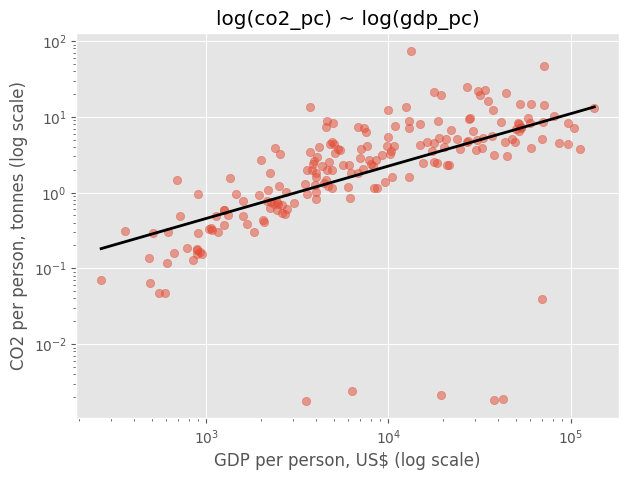

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(countries["gdp_pc"], countries["co2_pc"], alpha=0.5)
ax.plot(grid["gdp_pc"], np.exp(log_log.predict(grid)), color="black", linewidth=2)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("GDP per person, US$ (log scale)")
ax.set_ylabel("CO2 per person, tonnes (log scale)")
ax.set_title("log(co2_pc) ~ log(gdp_pc)")

plt.show()

On log axes the countries spread across the whole figure and the fitted line goes through the middle
of them rather than along one edge.

## 4. What the coefficient says

In [7]:
elasticity = log_log.params["np.log(gdp_pc)"]

print("elasticity:", round(elasticity, 3))
print(f"a country with 1% higher GDP per person emits about {elasticity:.2f}% more CO2 per person")
print(f"a country with 10% higher GDP per person emits about {elasticity * 10:.1f}% more")

elasticity: 0.691
a country with 1% higher GDP per person emits about 0.69% more CO2 per person
a country with 10% higher GDP per person emits about 6.9% more


**0.69.** Emissions rise with income, but less than proportionally - doubling income per person is
associated with something well short of doubling emissions per person.

Note what that sentence needs: no units, no reference level, and no "holding the intercept at zero
horsepower" fiction. That is why a log-log coefficient is the one people quote.

## 5. Adding controls, one at a time

In [8]:
controls = ["np.log(gdp_pc)", "renew_energy", "urban", "C(region)"]

specifications = []
for i in range(1, len(controls) + 1):
    specifications.append("np.log(co2_pc) ~ " + " + ".join(controls[:i]))

models = [smf.ols(spec, data=countries).fit() for spec in specifications]

comparison = pd.DataFrame({
    "model": [f"({i + 1})" for i in range(len(models))],
    "adj_r_squared": [m.rsquared_adj for m in models],
    "log_gdp": [m.params["np.log(gdp_pc)"] for m in models],
    "log_gdp_p": [m.pvalues["np.log(gdp_pc)"] for m in models],
}).round(4)

comparison

,model,adj_r_squared,log_gdp,log_gdp_p
0,(1),0.3111,0.6909,0.0000
1,(2),0.3361,0.5381,0.0000
2,(3),0.3347,0.4874,0.0000
3,(4),0.3677,0.4324,0.0009


### Does the elasticity survive?

**Yes, and it moves.** It starts at **0.691** and ends at **0.432**, a fall of about 37%, and it stays
comfortably significant throughout - the p-value is below 0.001 in every specification.

The interpretation changes with it, in exactly the way the lecture described. Model (1) compares any
two countries in the world. Model (4) compares two countries **in the same region, with the same
renewable share and the same level of urbanization** - and more than a third of the apparent income
effect turns out to belong to those things rather than to income. Both numbers are right; they answer
different questions.

`renew_energy` is worth a look too:

In [9]:
print("coefficient on renew_energy:", round(models[1].params["renew_energy"], 4))
print("p-value:                    ", round(models[1].pvalues["renew_energy"], 6))

coefficient on renew_energy: -0.0136
p-value:                     0.004605


Negative and significant: a country with a higher share of renewables in its energy mix emits less per
person at the same income. The size is small per percentage point, which is what you would expect from
a variable measured in percent.

## 6. Residuals

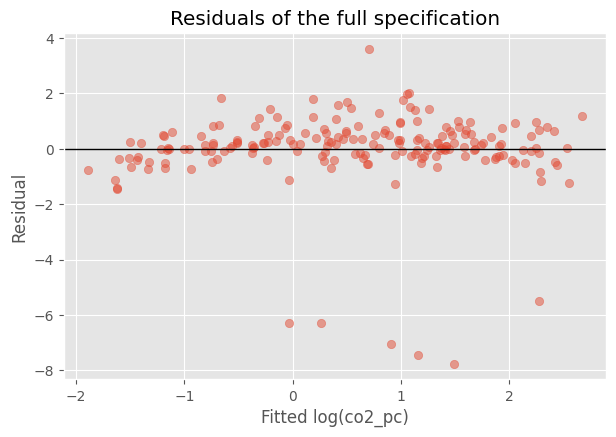

In [10]:
preferred = models[3]

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.scatter(preferred.fittedvalues, preferred.resid, alpha=0.5)
ax.axhline(0, color="black", linewidth=1)

ax.set_xlabel("Fitted log(co2_pc)")
ax.set_ylabel("Residual")
ax.set_title("Residuals of the full specification")

plt.show()

In [11]:
bands = pd.cut(preferred.fittedvalues, 6)

pd.DataFrame({"fitted": preferred.fittedvalues, "resid": preferred.resid}) \
    .groupby(bands, observed=True)["resid"].agg(["mean", "size"]).round(2)

,mean,size
"(-1.891, -1.128]",-0.37,21
"(-1.128, -0.369]",0.18,23
"(-0.369, 0.39]",-0.04,36
"(0.39, 1.149]",0.41,44
"(1.149, 1.908]",-0.17,46
"(1.908, 2.667]",-0.21,24


Much closer to a shapeless cloud than the fuel-economy residuals were: the band means run between
-0.37 and +0.41 with no U and no arc through them, against the straight-line fuel-economy model where
they ran from -1.6 to +7.

So: no obvious missing curve. That does **not** mean the model is right - it means the residual plot
has no complaint about the *shape*, which is the only thing it can tell you.

## 7. Getting it out

In [12]:
region_summary = (
    countries
    .groupby("region")
    .agg(
        countries=("co2_pc", "size"),
        mean_co2_pc=("co2_pc", "mean"),
        mean_gdp_pc=("gdp_pc", "mean"),
    )
    .round(1)
    .reset_index()
)

region_summary.to_excel("output-region-summary.xlsx", index=False)

print("written")
region_summary

written


,region,countries,mean_co2_pc,mean_gdp_pc
0,East Asia & Pacific,33,6.8,18577.6
1,Europe & Central Asia,48,6.1,33292.8
2,Latin America & Caribbean,37,2.9,14376.3
3,"Middle East, North Africa, Afghanistan & Pakistan",21,9.8,17282.9
4,North America,3,10.9,79031.0
5,South Asia,6,1.6,3953.2
6,Sub-Saharan Africa,46,0.9,2460.5


In [13]:
table = summary_col(
    models,
    stars=True,
    float_format="%0.3f",
    model_names=["(1)", "(2)", "(3)", "(4)"],
    regressor_order=["np.log(gdp_pc)", "renew_energy", "urban"],
    info_dict={"N": lambda m: f"{int(m.nobs)}"},
)

with open("output-emissions-models.tex", "w") as file:
    file.write(table.as_latex())

table

,(1),(2),(3),(4)
np.log(gdp_pc),0.691***,0.538***,0.487***,0.432***
,(0.074),(0.090),(0.111),(0.128)
renew_energy,,-0.014***,-0.013***,-0.011*
,,(0.005),(0.005),(0.006)
urban,,,0.005,0.003
,,,(0.006),(0.007)
Intercept,-5.558***,-3.791***,-3.652***,-3.594***
,(0.662),(0.896),(0.914),(1.062)
C(region)[T.Europe & Central Asia],,,,0.999***
,,,,(0.334)


Both files land in this week's folder and both are **derived** - the notebook made them and can make
them again, so neither belongs in git.

### Things worth noticing

- **The whole of Part 2 is in the first cell.** Read two files, rename a column, merge on a key that
  works, validate the merge, drop the aggregates, compute a per-person figure. Four weeks ago that was
  four weeks of material; here it is the setup before the exercise starts.
- **`np.exp` to draw a log-outcome model.** The model predicts `log(co2_pc)`, so plotting it against
  the original y-axis needs the log undone. Forgetting is a common and very visible mistake - the line
  comes out flat along the bottom.
- **The elasticity moving from 0.69 to 0.46** is the multiple-regression lesson from the lecture on
  different data: a coefficient is defined by what else is in the model.

### What this notebook does NOT do

- **It is one year.** Every number here describes 2021 and nothing here shows whether 2015 or 2019
  would say the same. The panel has 24 years in it and this exercise uses one row per country.
- **It says nothing about cause.** Countries that got richer did not necessarily emit more *because*
  they got richer, and a country that raised its renewable share would not necessarily see its
  emissions fall by the coefficient. Cross-sectional regression cannot distinguish those, and no
  amount of controls fixes it.
- **The nine dropped countries are never examined.** They were dropped for missing values, and missing
  values are rarely random - the countries with no data on renewable energy are systematically not
  like the ones with data.
- **Every country counts the same**, from China to Tuvalu. That is a choice, and a population-weighted
  regression would give a different answer to the same question.